# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [26]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score



In [27]:
# Load the dataset
df = pd.read_excel('colorectal_cancer_prediction.xlsx')


In [28]:
# Display basic information
df.head()


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Row Labels,Average of Age
2,No,54.359425
3,Yes,54.09308
4,Grand Total,54.332892


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4 non-null      object
 1   Unnamed: 1  4 non-null      object
dtypes: object(2)
memory usage: 212.0+ bytes


In [30]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()


""
0
1
2
3
4


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [31]:
import pandas as pd

xls = pd.ExcelFile("colorectal_cancer_prediction.xlsx")
xls.sheet_names


['Sheet3',
 'Sheet2',
 'Sheet4',
 'Sheet5',
 'Sheet6',
 'Sheet7',
 'colorectal_cancer_prediction',
 'Analysis Report',
 'Raw_Data']

In [32]:
import pandas as pd

df = pd.read_excel(
    "colorectal_cancer_prediction.xlsx",
    sheet_name="Raw_Data"
)

df.head()


,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


In [33]:
df = df.drop(columns=['Patient_ID'])


In [34]:

# Check for missing values
df.isnull().sum()


,0
Age,0
Gender,0
Race,0
Region,0
Urban_or_Rural,0
Socioeconomic_Status,0
Family_History,0
Previous_Cancer_History,0
Stage_at_Diagnosis,0
Tumor_Aggressiveness,0


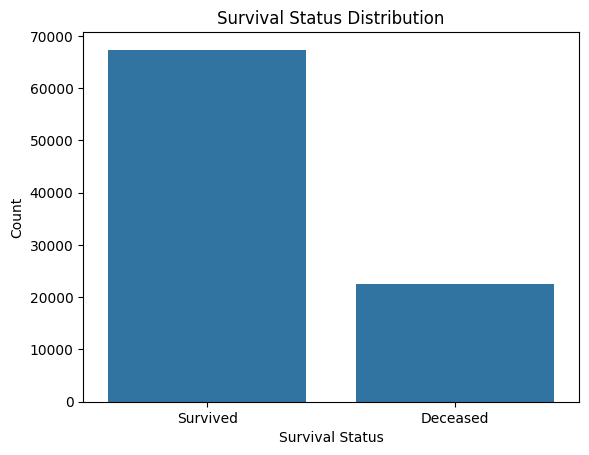

In [35]:
# Visualize survival status distribution
sns.countplot(x='Survival_Status', data=df)
plt.title("Survival Status Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.show()


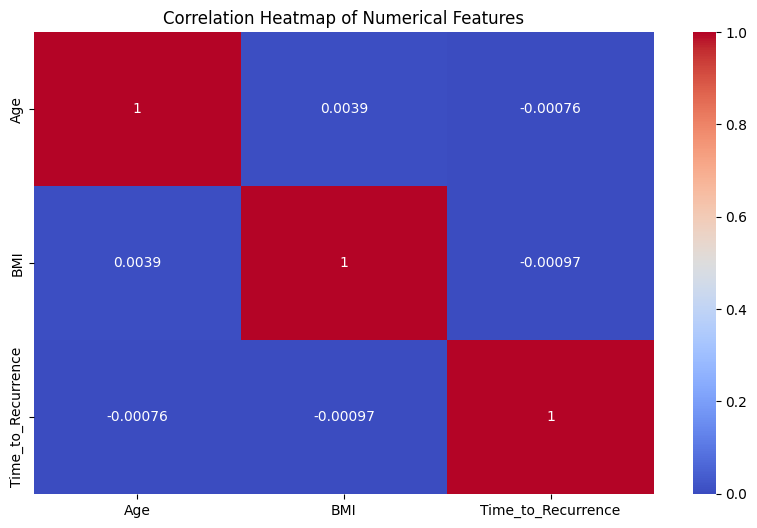

In [36]:
# Correlation heatmap (numerical features only)
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [37]:
import pandas as pd
import numpy as np


In [38]:
df = pd.read_excel(
    "colorectal_cancer_prediction.xlsx",
    sheet_name="Raw_Data"
)


In [39]:
df.head()


,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


In [40]:
# Drop unnecessary columns (e.g., Patient ID if present)
df = df.drop(columns=['Patient_ID'])


In [41]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,Age,BMI,Time_to_Recurrence,Gender_Male,Race_Black,Race_Hispanic,Race_Other,Race_White,Region_Asia Pacific,Region_Europe,...,Fiber_Consumption_Medium,Insurance_Coverage_Yes,Time_to_Diagnosis_Timely,Treatment_Access_Limited,Chemotherapy_Received_Yes,Radiotherapy_Received_Yes,Surgery_Received_Yes,Follow_Up_Adherence_Poor,Survival_Status_Survived,Recurrence_Yes
0,71,33.0,16,True,False,False,True,False,False,True,...,False,True,False,False,True,False,False,False,True,False
1,34,33.1,28,False,True,False,False,False,False,False,...,False,False,True,False,False,True,True,True,False,False
2,80,20.7,26,False,False,False,False,True,False,False,...,True,True,True,True,False,True,True,False,True,False
3,40,38.9,44,True,True,False,False,False,False,False,...,False,True,False,True,True,False,True,True,False,False
4,43,24.8,20,False,False,False,False,True,False,True,...,False,False,False,False,True,False,True,True,False,True


In [42]:
# Define features and target variable
# Adjust target column name as needed
y = df_encoded['Survival_Status_Survived']
X = df_encoded.drop(columns=['Survival_Status_Survived'])

X.shape, y.shape


((89945, 45), (89945,))

In [43]:
# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((71956, 45), (17989, 45))

## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [49]:

# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [48]:
# Predictions
y_pred = model.predict(X_test)


In [47]:
# Model evaluation
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [45]:
# print("Accuracy:", accuracy_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7514592250819946


In [46]:
# print("Classification Report:\n", classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.00      0.00      0.00      4471
        True       0.75      1.00      0.86     13518

    accuracy                           0.75     17989
   macro avg       0.38      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
